# Reproducing the neural set-propagation experiment

This notebook reproduces the computations and four plots for a fixed random feedforward network acting on the input set
\[
X_0=[0,1]^2 \subset \mathbb{R}^2.
\]

The network has:
- input dimension $2$,
- hidden width $30$,
- output dimension $2$,
- five affine layers in total,
- componentwise $\tanh$ activations after every affine layer except the last.

So the map is
\[
F = T_5 \circ \tanh \circ T_4 \circ \tanh \circ T_3 \circ \tanh \circ T_2 \circ \tanh \circ T_1.
\]

This notebook generates four figures:
1. the input square and a dense-sampling approximation of the image $F(X_0)$,
2. the interval-arithmetic (IA) enclosure overlaid with the sampled image,
3. the affine-arithmetic (AA) enclosure using the **min-range** $\tanh$ approximation,
4. the affine-arithmetic (AA) enclosure using the **Chebyshev** $\tanh$ approximation.

The notebook is self-contained and saves the figures into an output directory.


## Imports and configuration

We use the same fixed random seed and network-generation procedure as in the previous computation.


In [11]:
import math
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

# Fixed random seed and network width
seed = 3
width = 30
rng = np.random.default_rng(seed)

# Directory for saved figures
outdir = Path("neural_set_propagation_outputs")
outdir.mkdir(exist_ok=True)

print(f"seed = {seed}")
print(f"hidden width = {width}")
print(f"figure output directory = {outdir.resolve()}")


seed = 3
hidden width = 30
figure output directory = /users/mmaibaum/projects/neural_set_propagation_outputs


## Build the random network

The dimensions are
\[
2 \to 30 \to 30 \to 30 \to 30 \to 2.
\]

Each affine layer has the form $T_i(x)=W_i x + b_i$.  
The same random network is used in all four plots.


In [12]:
dims = [2, width, width, width, width, 2]

Ws = []
bs = []
for din, dout in zip(dims[:-1], dims[1:]):
    scale = 0.7 / math.sqrt(din)
    W = rng.normal(0.0, scale, size=(dout, din))
    b = rng.normal(0.0, 0.15, size=(dout,))
    Ws.append(W)
    bs.append(b)

print("Network architecture:")
for i, (W, b) in enumerate(zip(Ws, bs), start=1):
    print(f"T{i}: W shape = {W.shape}, b shape = {b.shape}")


Network architecture:
T1: W shape = (30, 2), b shape = (30,)
T2: W shape = (30, 30), b shape = (30,)
T3: W shape = (30, 30), b shape = (30,)
T4: W shape = (30, 30), b shape = (30,)
T5: W shape = (2, 30), b shape = (2,)


## Forward map on point samples

This is the standard pointwise forward evaluation of the network.  
We use it to generate a dense-sampling approximation of the image $F(X_0)$.


In [13]:
def forward_points(X: np.ndarray) -> np.ndarray:
    """Forward evaluation on a batch of input points of shape (N, 2)."""
    A = X
    for i, (W, b) in enumerate(zip(Ws, bs)):
        A = A @ W.T + b
        if i < len(Ws) - 1:
            A = np.tanh(A)
    return A


## Interval arithmetic (IA) propagation

For an interval box $[\ell, u]$, an affine map is propagated by splitting each matrix into positive and negative parts:
\[
W = W_+ + W_-,
\qquad
W_+ = \max(W,0),\quad W_- = \min(W,0).
\]
Then
\[
[\ell',u'] = [W_+\ell + W_- u + b,\; W_+ u + W_- \ell + b].
\]

Since $\tanh$ is monotone increasing, it is applied coordinatewise to the endpoints.


In [14]:
def ia_propagate(lo: np.ndarray, hi: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    """Propagate an interval box through the network using interval arithmetic."""
    for i, (W, b) in enumerate(zip(Ws, bs)):
        W_pos = np.maximum(W, 0.0)
        W_neg = np.minimum(W, 0.0)

        new_lo = W_pos @ lo + W_neg @ hi + b
        new_hi = W_pos @ hi + W_neg @ lo + b
        lo, hi = new_lo, new_hi

        if i < len(Ws) - 1:
            lo = np.tanh(lo)
            hi = np.tanh(hi)

    return lo, hi


## Affine arithmetic (AA) propagation

An affine form is represented as
\[
x = c + G \varepsilon,
\qquad
\varepsilon \in [-1,1]^m.
\]

The affine part propagates exactly:
\[
x \mapsto W x + b \;\Rightarrow\; (c,G) \mapsto (Wc+b, WG).
\]

For the nonlinearities, we approximate $\tanh$ on each coordinate interval by an affine bound
\[
\tanh(t) \approx p\,t + q \pm \Delta.
\]

We implement two choices:
- **min-range**, minimizing the width of the resulting affine interval enclosure,
- **Chebyshev**, minimizing the maximum scalar approximation error $\Delta$.

After applying the scalar approximation to each coordinate, a fresh independent error symbol is introduced per coordinate.


In [5]:
def affine_interval(center: np.ndarray, generators: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    """Return the interval hull of an affine form."""
    rad = np.sum(np.abs(generators), axis=1)
    return center - rad, center + rad


def tanh_residual_extrema(l: float, u: float, p: float) -> tuple[float, float]:
    """
    For r(x) = tanh(x) - p x on [l,u], compute q and Delta such that
        |p x + q - tanh(x)| <= Delta  on [l,u].
    The extrema of r occur at endpoints or where sech^2(x) = p.
    """
    candidates = [l, u]

    if 0.0 < p <= 1.0:
        x0 = float(np.arccosh(1.0 / np.sqrt(p)))
        if l <= x0 <= u:
            candidates.append(x0)
        if l <= -x0 <= u:
            candidates.append(-x0)

    xs = np.array(candidates, dtype=float)
    vals = np.tanh(xs) - p * xs
    m = float(vals.min())
    M = float(vals.max())

    q = 0.5 * (M + m)
    Delta = 0.5 * (M - m)
    return q, Delta


def optimize_tanh_affine(l: float, u: float, mode: str) -> tuple[float, float, float]:
    """
    Find (p,q,Delta) for tanh on [l,u].

    mode = 'min_range' or 'chebyshev'
      - chebyshev minimizes Delta
      - min_range minimizes p*r + Delta, where r = (u-l)/2
    """
    r = 0.5 * (u - l)
    phi = (math.sqrt(5.0) - 1.0) / 2.0
    a, b = 0.0, 1.0  # slope search interval for tanh

    def objective(p: float) -> float:
        q, Delta = tanh_residual_extrema(l, u, p)
        if mode == "chebyshev":
            return Delta
        return p * r + Delta

    c = b - phi * (b - a)
    d = a + phi * (b - a)
    fc = objective(c)
    fd = objective(d)

    for _ in range(80):
        if fc > fd:
            a = c
            c = d
            fc = fd
            d = a + phi * (b - a)
            fd = objective(d)
        else:
            b = d
            d = c
            fd = fc
            c = b - phi * (b - a)
            fc = objective(c)

    p = 0.5 * (a + b)
    q, Delta = tanh_residual_extrema(l, u, p)
    return p, q, Delta


def aa_propagate(mode: str) -> tuple[np.ndarray, np.ndarray]:
    """
    Propagate the input square [0,1]^2 through the network using affine arithmetic.

    Returns:
        center, generators
    """
    # Input square [0,1]^2 as affine form:
    # center = (0.5, 0.5), generators = diag(0.5, 0.5)
    center = np.array([0.5, 0.5], dtype=float)
    generators = np.array([[0.5, 0.0], [0.0, 0.5]], dtype=float)

    for i, (W, b) in enumerate(zip(Ws, bs)):
        center = W @ center + b
        generators = W @ generators

        if i < len(Ws) - 1:
            lo, hi = affine_interval(center, generators)

            n = center.shape[0]
            old_m = generators.shape[1]

            new_center = np.empty_like(center)
            new_generators = np.zeros((n, old_m + n), dtype=float)

            for j in range(n):
                p, q, Delta = optimize_tanh_affine(float(lo[j]), float(hi[j]), mode)
                new_center[j] = p * center[j] + q
                new_generators[j, :old_m] = p * generators[j, :]
                new_generators[j, old_m + j] = Delta

            center = new_center
            generators = new_generators

    return center, generators


## A polygon for a 2D zonotope

The AA output in $\mathbb{R}^2$ is again a zonotope.  
To plot it, we convert the affine form $(c,G)$ into an ordered polygon boundary.


In [6]:
def zonotope_polygon_2d(center: np.ndarray, generators: np.ndarray, tol: float = 1e-12) -> np.ndarray:
    """
    Construct an ordered polygon for a 2D zonotope center + G[-1,1]^m.

    The method keeps one representative of each generator segment in the upper half-plane,
    sorts by angle there, and performs the standard edge sweep.
    """
    G = np.asarray(generators, dtype=float).copy()
    norms = np.linalg.norm(G, axis=0)
    G = G[:, norms > tol]

    if G.shape[1] == 0:
        return np.array([center], dtype=float)

    # Flip generators to a common half-plane representation
    for j in range(G.shape[1]):
        x, y = G[:, j]
        if (y < 0.0) or (abs(y) < tol and x < 0.0):
            G[:, j] = -G[:, j]

    angles = np.arctan2(G[1, :], G[0, :])
    order = np.argsort(angles)
    G = G[:, order]

    v = center - np.sum(G, axis=1)
    verts = [v.copy()]

    for j in range(G.shape[1]):
        v = v + 2.0 * G[:, j]
        verts.append(v.copy())

    for j in range(G.shape[1]):
        v = v - 2.0 * G[:, j]
        verts.append(v.copy())

    return np.array(verts[:-1], dtype=float)


def close_poly(P: np.ndarray) -> np.ndarray:
    return np.vstack([P, P[0]])


def combined_limits(arrays, pad=0.06):
    all_pts = np.vstack(arrays)
    xmin, ymin = np.min(all_pts, axis=0)
    xmax, ymax = np.max(all_pts, axis=0)
    dx = xmax - xmin
    dy = ymax - ymin
    xpad = pad * dx if dx > 0 else 0.05
    ypad = pad * dy if dy > 0 else 0.05
    return (xmin - xpad, xmax + xpad), (ymin - ypad, ymax + ypad)


def style_axes(ax, xlim, ylim, title):
    ax.set_title(title)
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_aspect("equal")
    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)
    ax.grid(True, alpha=0.3)


## Approximate the exact image by dense sampling

We sample the input square $X_0=[0,1]^2$ on a dense $350 \times 350$ grid and push those points through the network.  
This gives a high-resolution approximation of the true image $F(X_0)$.


In [7]:
# Dense grid on the input square
n_grid = 350
xs = np.linspace(0.0, 1.0, n_grid)
ys = np.linspace(0.0, 1.0, n_grid)
X0_grid = np.stack(np.meshgrid(xs, ys), axis=-1).reshape(-1, 2)

# Approximate exact image
Y_exact = forward_points(X0_grid)

# Input square polygon
X0_square = np.array(
    [
        [0.0, 0.0],
        [1.0, 0.0],
        [1.0, 1.0],
        [0.0, 1.0],
    ],
    dtype=float,
)

print("Approximate exact image bounds from dense sampling:")
print(f"x in [{Y_exact[:,0].min():.6f}, {Y_exact[:,0].max():.6f}]")
print(f"y in [{Y_exact[:,1].min():.6f}, {Y_exact[:,1].max():.6f}]")


Approximate exact image bounds from dense sampling:
x in [0.098800, 0.161177]
y in [0.302682, 0.544558]


## Compute the IA and AA propagated sets

In [15]:
# IA output box
ia_lo, ia_hi = ia_propagate(np.array([0.0, 0.0]), np.array([1.0, 1.0]))
IA_box = np.array(
    [
        [ia_lo[0], ia_lo[1]],
        [ia_hi[0], ia_lo[1]],
        [ia_hi[0], ia_hi[1]],
        [ia_lo[0], ia_hi[1]],
    ],
    dtype=float,
)

# AA outputs
aa_min_center, aa_min_generators = aa_propagate("min_range")
aa_cheb_center, aa_cheb_generators = aa_propagate("chebyshev")

AA_min_poly = zonotope_polygon_2d(aa_min_center, aa_min_generators)
AA_cheb_poly = zonotope_polygon_2d(aa_cheb_center, aa_cheb_generators)

# Interval hulls of AA outputs
aa_min_lo, aa_min_hi = affine_interval(aa_min_center, aa_min_generators)
aa_cheb_lo, aa_cheb_hi = affine_interval(aa_cheb_center, aa_cheb_generators)

print("IA output box:")
print(f"x in [{ia_lo[0]:.6f}, {ia_hi[0]:.6f}]")
print(f"y in [{ia_lo[1]:.6f}, {ia_hi[1]:.6f}]")

print("AA min-range interval hull:")
print(f"x in [{aa_min_lo[0]:.6f}, {aa_min_hi[0]:.6f}]")
print(f"y in [{aa_min_lo[1]:.6f}, {aa_min_hi[1]:.6f}]")

print("AA Chebyshev interval hull:")
print(f"x in [{aa_cheb_lo[0]:.6f}, {aa_cheb_hi[0]:.6f}]")
print(f"y in [{aa_cheb_lo[1]:.6f}, {aa_cheb_hi[1]:.6f}]")


IA output box:
x in [-3.001070, 3.330105]
y in [-2.859557, 3.083501]
AA min-range interval hull:
x in [-2.970328, 3.297714]
y in [-2.825798, 3.051450]
AA Chebyshev interval hull:
x in [0.064229, 0.203212]
y in [0.239840, 0.597575]


## Plot 1: input square and approximate exact image

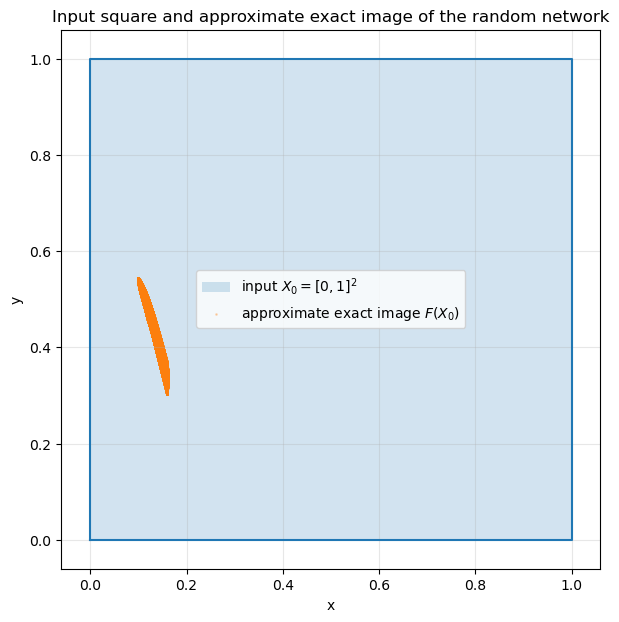

/users/mmaibaum/projects/neural_set_propagation_outputs/plot_1_exact_image.png


In [16]:
fig1, ax1 = plt.subplots(figsize=(7, 7))

sq_closed = close_poly(X0_square)
ax1.fill(X0_square[:, 0], X0_square[:, 1], alpha=0.20, label=r"input $X_0=[0,1]^2$")
ax1.plot(sq_closed[:, 0], sq_closed[:, 1])

ax1.scatter(
    Y_exact[:, 0],
    Y_exact[:, 1],
    s=1,
    alpha=0.25,
    label=r"approximate exact image $F(X_0)$",
)

xlim1, ylim1 = combined_limits([X0_square, Y_exact])
style_axes(ax1, xlim1, ylim1, "Input square and approximate exact image of the random network")
ax1.legend()

path1 = outdir / "plot_1_exact_image.png"
fig1.savefig(path1, dpi=220, bbox_inches="tight")
plt.show()

print(path1.resolve())


## Plot 2: IA enclosure and approximate exact image

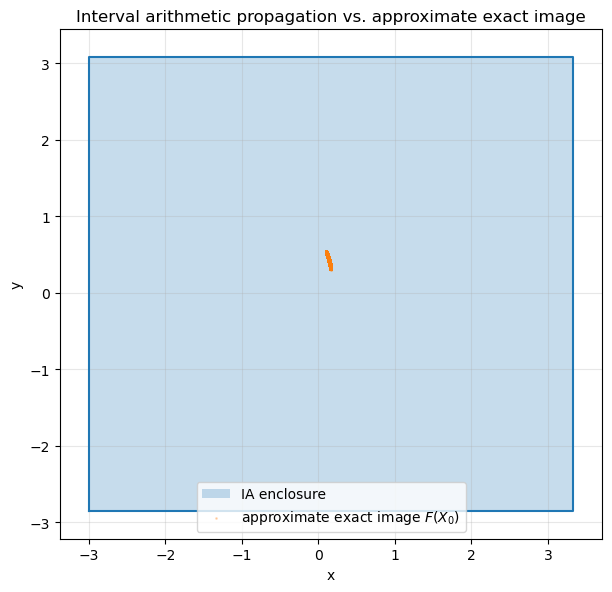

/users/mmaibaum/projects/neural_set_propagation_outputs/plot_2_ia.png


In [17]:
fig2, ax2 = plt.subplots(figsize=(7, 7))

ia_closed = close_poly(IA_box)
ax2.fill(IA_box[:, 0], IA_box[:, 1], alpha=0.25, label="IA enclosure")
ax2.plot(ia_closed[:, 0], ia_closed[:, 1])

ax2.scatter(
    Y_exact[:, 0],
    Y_exact[:, 1],
    s=1,
    alpha=0.25,
    label=r"approximate exact image $F(X_0)$",
)

xlim2, ylim2 = combined_limits([IA_box, Y_exact])
style_axes(ax2, xlim2, ylim2, "Interval arithmetic propagation vs. approximate exact image")
ax2.legend()

path2 = outdir / "plot_2_ia.png"
fig2.savefig(path2, dpi=220, bbox_inches="tight")
plt.show()

print(path2.resolve())


## Plot 3: AA min-range enclosure and approximate exact image

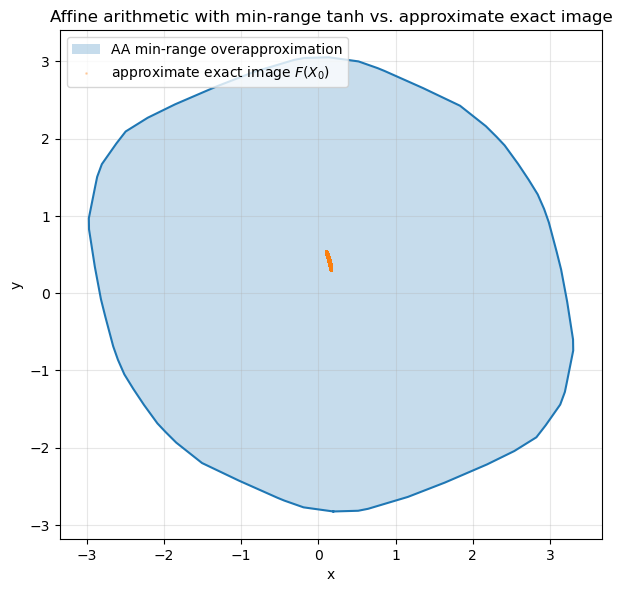

/users/mmaibaum/projects/neural_set_propagation_outputs/plot_3_aa_min_range.png


In [18]:
fig3, ax3 = plt.subplots(figsize=(7, 7))

aa_min_closed = close_poly(AA_min_poly)
ax3.fill(AA_min_poly[:, 0], AA_min_poly[:, 1], alpha=0.25, label="AA min-range overapproximation")
ax3.plot(aa_min_closed[:, 0], aa_min_closed[:, 1])

ax3.scatter(
    Y_exact[:, 0],
    Y_exact[:, 1],
    s=1,
    alpha=0.25,
    label=r"approximate exact image $F(X_0)$",
)

xlim3, ylim3 = combined_limits([AA_min_poly, Y_exact])
style_axes(ax3, xlim3, ylim3, "Affine arithmetic with min-range tanh vs. approximate exact image")
ax3.legend()

path3 = outdir / "plot_3_aa_min_range.png"
fig3.savefig(path3, dpi=220, bbox_inches="tight")
plt.show()

print(path3.resolve())


## Plot 4: AA Chebyshev enclosure and approximate exact image

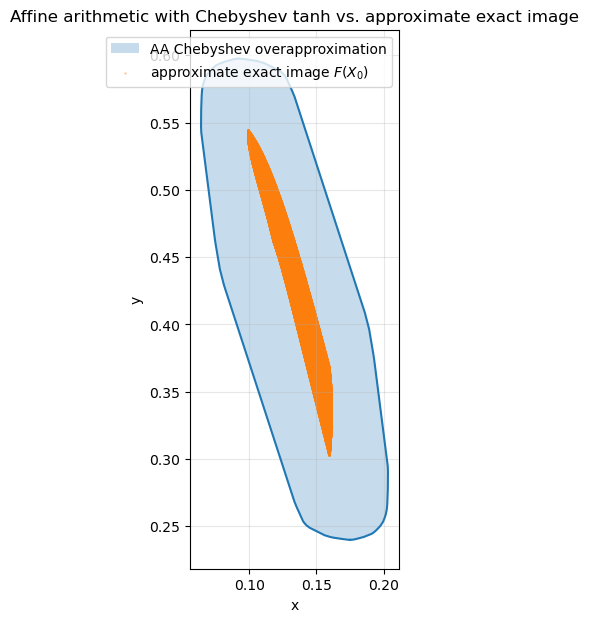

/users/mmaibaum/projects/neural_set_propagation_outputs/plot_4_aa_chebyshev.png


In [19]:
fig4, ax4 = plt.subplots(figsize=(7, 7))

aa_cheb_closed = close_poly(AA_cheb_poly)
ax4.fill(AA_cheb_poly[:, 0], AA_cheb_poly[:, 1], alpha=0.25, label="AA Chebyshev overapproximation")
ax4.plot(aa_cheb_closed[:, 0], aa_cheb_closed[:, 1])

ax4.scatter(
    Y_exact[:, 0],
    Y_exact[:, 1],
    s=1,
    alpha=0.25,
    label=r"approximate exact image $F(X_0)$",
)

xlim4, ylim4 = combined_limits([AA_cheb_poly, Y_exact])
style_axes(ax4, xlim4, ylim4, "Affine arithmetic with Chebyshev tanh vs. approximate exact image")
ax4.legend()

path4 = outdir / "plot_4_aa_chebyshev.png"
fig4.savefig(path4, dpi=220, bbox_inches="tight")
plt.show()

print(path4.resolve())


## Summary

Running this notebook from top to bottom reproduces:
- the same fixed random network,
- the same dense-sampling approximation of the image of $X_0=[0,1]^2$,
- the same IA propagation,
- the same AA min-range propagation,
- the same AA Chebyshev propagation,
- and the same four saved figures.


## Repeat the enclosures with intervalNets IA/AA code

This section reproduces the same plot family for the **same random network**,
but computes IA/AA enclosures using `intervalnets` (`IntervalTensor` and `AffineTensor`).


In [ ]:
import torch
from torch import nn

from intervalnets import IntervalTensor, AffineTensor, interval_forward, affine_forward


In [ ]:
# Build the identical network in torch using the same sampled Ws, bs
torch.set_default_dtype(torch.float64)

layers = []
for i, (W_np, b_np) in enumerate(zip(Ws, bs)):
    W_t = torch.tensor(W_np, dtype=torch.float64)
    b_t = torch.tensor(b_np, dtype=torch.float64)
    lin = nn.Linear(W_t.shape[1], W_t.shape[0], bias=True, dtype=torch.float64)
    with torch.no_grad():
        lin.weight.copy_(W_t)
        lin.bias.copy_(b_t)
    layers.append(lin)
    if i < len(Ws) - 1:
        layers.append(nn.Tanh())

model_torch = nn.Sequential(*layers).eval()

# intervalNets IA and AA propagation on X0 = [0,1]^2
X0_interval = IntervalTensor.from_bounds([0.0, 0.0], [1.0, 1.0])
Y_ia_intervalnets = interval_forward(model_torch, X0_interval, enclosure_mode="box")
ia2_lo = np.array(Y_ia_intervalnets.lower, dtype=float)
ia2_hi = np.array(Y_ia_intervalnets.upper, dtype=float)

X0_affine = AffineTensor.from_bounds(
    torch.tensor([0.0, 0.0], dtype=torch.float64),
    torch.tensor([1.0, 1.0], dtype=torch.float64),
)

Y_aa_intervalnets_min = affine_forward(model_torch, X0_affine, affine_tanh_mode="min_range")
aa2_min_lo_t, aa2_min_hi_t = Y_aa_intervalnets_min.to_bounds()
aa2_min_lo = aa2_min_lo_t.detach().cpu().numpy().astype(float)
aa2_min_hi = aa2_min_hi_t.detach().cpu().numpy().astype(float)
aa2_min_center = Y_aa_intervalnets_min.c.detach().cpu().numpy().astype(float)
aa2_min_generators = Y_aa_intervalnets_min.G.detach().cpu().numpy().astype(float)

Y_aa_intervalnets_cheb = affine_forward(model_torch, X0_affine, affine_tanh_mode="chebyshev")
aa2_cheb_lo_t, aa2_cheb_hi_t = Y_aa_intervalnets_cheb.to_bounds()
aa2_cheb_lo = aa2_cheb_lo_t.detach().cpu().numpy().astype(float)
aa2_cheb_hi = aa2_cheb_hi_t.detach().cpu().numpy().astype(float)
aa2_cheb_center = Y_aa_intervalnets_cheb.c.detach().cpu().numpy().astype(float)
aa2_cheb_generators = Y_aa_intervalnets_cheb.G.detach().cpu().numpy().astype(float)

IA2_box = np.array(
    [
        [ia2_lo[0], ia2_lo[1]],
        [ia2_hi[0], ia2_lo[1]],
        [ia2_hi[0], ia2_hi[1]],
        [ia2_lo[0], ia2_hi[1]],
    ],
    dtype=float,
)
AA2_min_poly = zonotope_polygon_2d(aa2_min_center, aa2_min_generators)
AA2_cheb_poly = zonotope_polygon_2d(aa2_cheb_center, aa2_cheb_generators)

print("intervalNets IA output box:")
print(f"x in [{ia2_lo[0]:.6f}, {ia2_hi[0]:.6f}]")
print(f"y in [{ia2_lo[1]:.6f}, {ia2_hi[1]:.6f}]")

print("intervalNets AA min-range interval hull:")
print(f"x in [{aa2_min_lo[0]:.6f}, {aa2_min_hi[0]:.6f}]")
print(f"y in [{aa2_min_lo[1]:.6f}, {aa2_min_hi[1]:.6f}]")

print("intervalNets AA Chebyshev interval hull:")
print(f"x in [{aa2_cheb_lo[0]:.6f}, {aa2_cheb_hi[0]:.6f}]")
print(f"y in [{aa2_cheb_lo[1]:.6f}, {aa2_cheb_hi[1]:.6f}]")


## Plot 5: (intervalNets) input square and approximate exact image


In [ ]:
fig5, ax5 = plt.subplots(figsize=(7, 7))

sq_closed = close_poly(X0_square)
ax5.fill(X0_square[:, 0], X0_square[:, 1], alpha=0.20, label=r"input $X_0=[0,1]^2$")
ax5.plot(sq_closed[:, 0], sq_closed[:, 1])

ax5.scatter(
    Y_exact[:, 0],
    Y_exact[:, 1],
    s=1,
    alpha=0.25,
    label=r"approximate exact image $F(X_0)$",
)

xlim5, ylim5 = combined_limits([X0_square, Y_exact])
style_axes(ax5, xlim5, ylim5, "(intervalNets run) Input square and approximate exact image")
ax5.legend()

path5 = outdir / "plot_5_intervalnets_exact_image.png"
fig5.savefig(path5, dpi=220, bbox_inches="tight")
plt.show()

print(path5.resolve())


## Plot 6: (intervalNets IA) enclosure and approximate exact image


In [ ]:
fig6, ax6 = plt.subplots(figsize=(7, 7))

ia2_closed = close_poly(IA2_box)
ax6.fill(IA2_box[:, 0], IA2_box[:, 1], alpha=0.25, label="intervalNets IA enclosure")
ax6.plot(ia2_closed[:, 0], ia2_closed[:, 1])

ax6.scatter(
    Y_exact[:, 0],
    Y_exact[:, 1],
    s=1,
    alpha=0.25,
    label=r"approximate exact image $F(X_0)$",
)

xlim6, ylim6 = combined_limits([IA2_box, Y_exact])
style_axes(ax6, xlim6, ylim6, "intervalNets interval propagation vs. approximate exact image")
ax6.legend()

path6 = outdir / "plot_6_intervalnets_ia.png"
fig6.savefig(path6, dpi=220, bbox_inches="tight")
plt.show()

print(path6.resolve())


## Plot 7: (intervalNets AA min-range) zonotope overapproximation and approximate exact image


In [ ]:
fig7, ax7 = plt.subplots(figsize=(7, 7))

aa2_min_closed = close_poly(AA2_min_poly)
ax7.fill(AA2_min_poly[:, 0], AA2_min_poly[:, 1], alpha=0.25, label="intervalNets AA min-range overapproximation")
ax7.plot(aa2_min_closed[:, 0], aa2_min_closed[:, 1])

ax7.scatter(
    Y_exact[:, 0],
    Y_exact[:, 1],
    s=1,
    alpha=0.25,
    label=r"approximate exact image $F(X_0)$",
)

xlim7, ylim7 = combined_limits([AA2_min_poly, Y_exact])
style_axes(ax7, xlim7, ylim7, "intervalNets affine min-range propagation vs. approximate exact image")
ax7.legend()

path7 = outdir / "plot_7_intervalnets_aa_min_range.png"
fig7.savefig(path7, dpi=220, bbox_inches="tight")
plt.show()

print(path7.resolve())


## Plot 8: (intervalNets AA Chebyshev) zonotope overapproximation and approximate exact image


In [ ]:
fig8, ax8 = plt.subplots(figsize=(7, 7))

aa2_cheb_closed = close_poly(AA2_cheb_poly)
ax8.fill(AA2_cheb_poly[:, 0], AA2_cheb_poly[:, 1], alpha=0.25, label="intervalNets AA Chebyshev overapproximation")
ax8.plot(aa2_cheb_closed[:, 0], aa2_cheb_closed[:, 1])

ax8.scatter(
    Y_exact[:, 0],
    Y_exact[:, 1],
    s=1,
    alpha=0.25,
    label=r"approximate exact image $F(X_0)$",
)

xlim8, ylim8 = combined_limits([AA2_cheb_poly, Y_exact])
style_axes(ax8, xlim8, ylim8, "intervalNets affine Chebyshev propagation vs. approximate exact image")
ax8.legend()

path8 = outdir / "plot_8_intervalnets_aa_chebyshev.png"
fig8.savefig(path8, dpi=220, bbox_inches="tight")
plt.show()

print(path8.resolve())


## Plot 9: (intervalNets AA min-range interval hull) box enclosure and approximate exact image


In [ ]:
AA2_min_hull_box = np.array(
    [
        [aa2_min_lo[0], aa2_min_lo[1]],
        [aa2_min_hi[0], aa2_min_lo[1]],
        [aa2_min_hi[0], aa2_min_hi[1]],
        [aa2_min_lo[0], aa2_min_hi[1]],
    ],
    dtype=float,
)

fig9, ax9 = plt.subplots(figsize=(7, 7))

aa2_hull_closed = close_poly(AA2_min_hull_box)
ax9.fill(AA2_min_hull_box[:, 0], AA2_min_hull_box[:, 1], alpha=0.25, label="intervalNets AA min-range interval hull")
ax9.plot(aa2_hull_closed[:, 0], aa2_hull_closed[:, 1])

ax9.scatter(
    Y_exact[:, 0],
    Y_exact[:, 1],
    s=1,
    alpha=0.25,
    label=r"approximate exact image $F(X_0)$",
)

xlim9, ylim9 = combined_limits([AA2_min_hull_box, Y_exact])
style_axes(ax9, xlim9, ylim9, "intervalNets affine min-range interval hull vs. approximate exact image")
ax9.legend()

path9 = outdir / "plot_9_intervalnets_aa_min_hull.png"
fig9.savefig(path9, dpi=220, bbox_inches="tight")
plt.show()

print(path9.resolve())
